In [109]:

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
import time 
import datetime 
     

In [110]:
orig_df = pd.read_csv(
    r"C:\Users\USER\Time_series\testset.csv",
    low_memory=False
)

In [111]:
print(orig_df.shape)
print(orig_df.columns)
print(orig_df.head())

(100990, 20)
Index(['datetime_utc', ' _conds', ' _dewptm', ' _fog', ' _hail',
       ' _heatindexm', ' _hum', ' _precipm', ' _pressurem', ' _rain', ' _snow',
       ' _tempm', ' _thunder', ' _tornado', ' _vism', ' _wdird', ' _wdire',
       ' _wgustm', ' _windchillm', ' _wspdm'],
      dtype='object')
     datetime_utc  _conds   _dewptm   _fog   _hail   _heatindexm   _hum  \
0  19961101-11:00   Smoke       9.0      0       0           NaN   27.0   
1  19961101-12:00   Smoke      10.0      0       0           NaN   32.0   
2  19961101-13:00   Smoke      11.0      0       0           NaN   44.0   
3  19961101-14:00   Smoke      10.0      0       0           NaN   41.0   
4  19961101-16:00   Smoke      11.0      0       0           NaN   47.0   

    _precipm   _pressurem   _rain   _snow   _tempm   _thunder   _tornado  \
0        NaN       1010.0       0       0     30.0          0          0   
1        NaN      -9999.0       0       0     28.0          0          0   
2        NaN      

In [112]:
df = orig_df.copy()

df.columns = df.columns.str.strip()

df = df[['datetime_utc', '_tempm', '_pressurem', '_hum']]

df.columns = ['Date', 'Temperature', 'Pressure', 'Humidity']

print(df.head())

             Date  Temperature  Pressure  Humidity
0  19961101-11:00         30.0    1010.0      27.0
1  19961101-12:00         28.0   -9999.0      32.0
2  19961101-13:00         24.0   -9999.0      44.0
3  19961101-14:00         24.0    1010.0      41.0
4  19961101-16:00         23.0    1011.0      47.0


In [113]:
df.describe()

,Temperature,Pressure,Humidity
count,100317.000000,1.007580e+05,100233.000000
mean,25.451269,1.932331e+03,57.909481
std,8.482859,3.183786e+05,23.807771
min,1.000000,-9.999000e+03,4.000000
25%,19.000000,1.002000e+03,39.000000
50%,27.000000,1.008000e+03,59.000000
75%,32.000000,1.014000e+03,78.000000
max,90.000000,1.010614e+08,243.000000


In [114]:
df = df[(df['Humidity'] >= 39) & (df['Humidity'] <= 78)]
df = df[(df['Pressure'] >= 1002.0) & (df['Pressure'] <= 1014.0)]
df = df[(df['Temperature'] >= 19.0) & (df['Temperature'] <= 32.0)]

max_temp = np.max(df['Temperature'])
max_pres = np.max(df['Pressure'])
max_humid = np.max(df['Humidity'])

min_temp = np.min(df['Temperature'])
min_pres = np.min(df['Pressure'])
min_humid = np.min(df['Humidity'])

print(f'Max Temp : {max_temp}')
print(f'Max Pressure : {max_pres}')
print(f'Max Humidity : {max_humid}')

print(f'Min Temp : {min_temp}')
print(f'Min Pressure : {min_pres}')
print(f'Min Humidity : {min_humid}')

Max Temp : 32.0
Max Pressure : 1014.0
Max Humidity : 78.0
Min Temp : 19.0
Min Pressure : 1002.0
Min Humidity : 39.0


In [115]:
df.isnull().sum()

Date           0
Temperature    0
Pressure       0
Humidity       0
dtype: int64

In [116]:
df.shape
     

(19874, 4)

In [117]:
df.head()

,Date,Temperature,Pressure,Humidity
3,19961101-14:00,24.0,1010.0,41.0
4,19961101-16:00,23.0,1011.0,47.0
5,19961101-17:00,21.0,1011.0,56.0
6,19961101-18:00,21.0,1010.0,60.0
9,19961101-21:00,19.0,1010.0,68.0


In [118]:
temp_df = df[df['Date'].str.contains('14:') == True]
temp_df.shape

(626, 4)

In [119]:
temp_df.head()

,Date,Temperature,Pressure,Humidity
3,19961101-14:00,24.0,1010.0,41.0
26,19961102-14:00,22.0,1010.0,53.0
50,19961103-14:00,22.0,1011.0,57.0
90,19961106-14:00,20.0,1012.0,52.0
113,19961107-14:00,22.0,1014.0,46.0


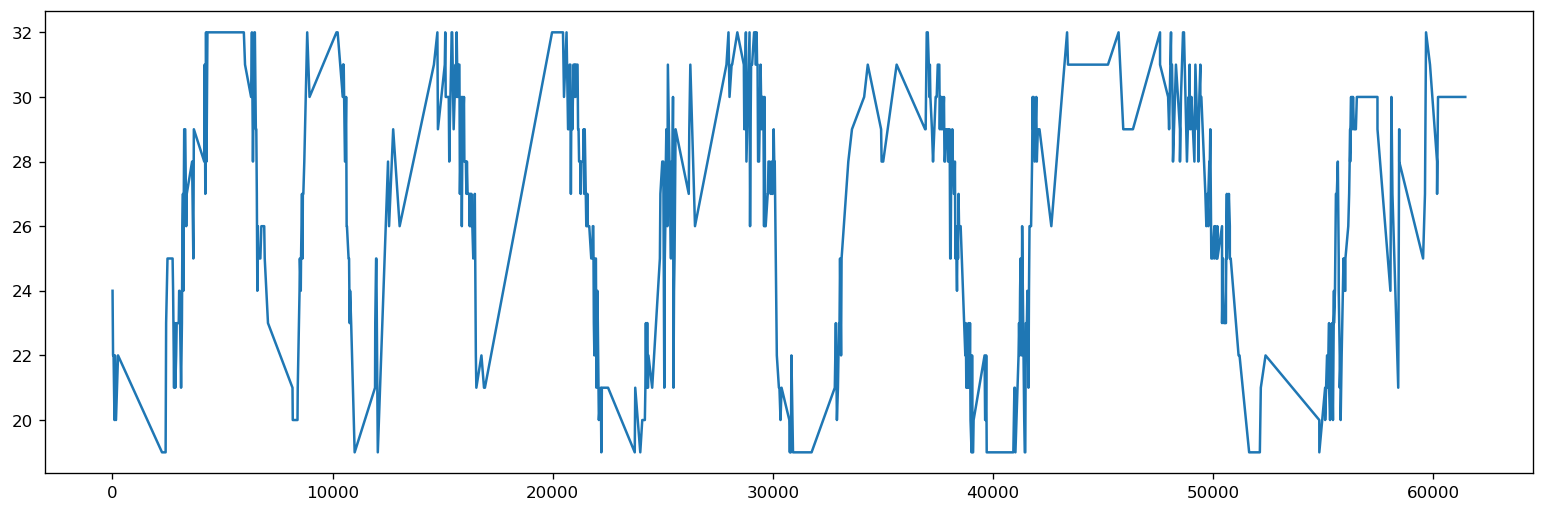

In [120]:

plt.figure(figsize = (16,5))
plt.plot(temp_df['Temperature'])

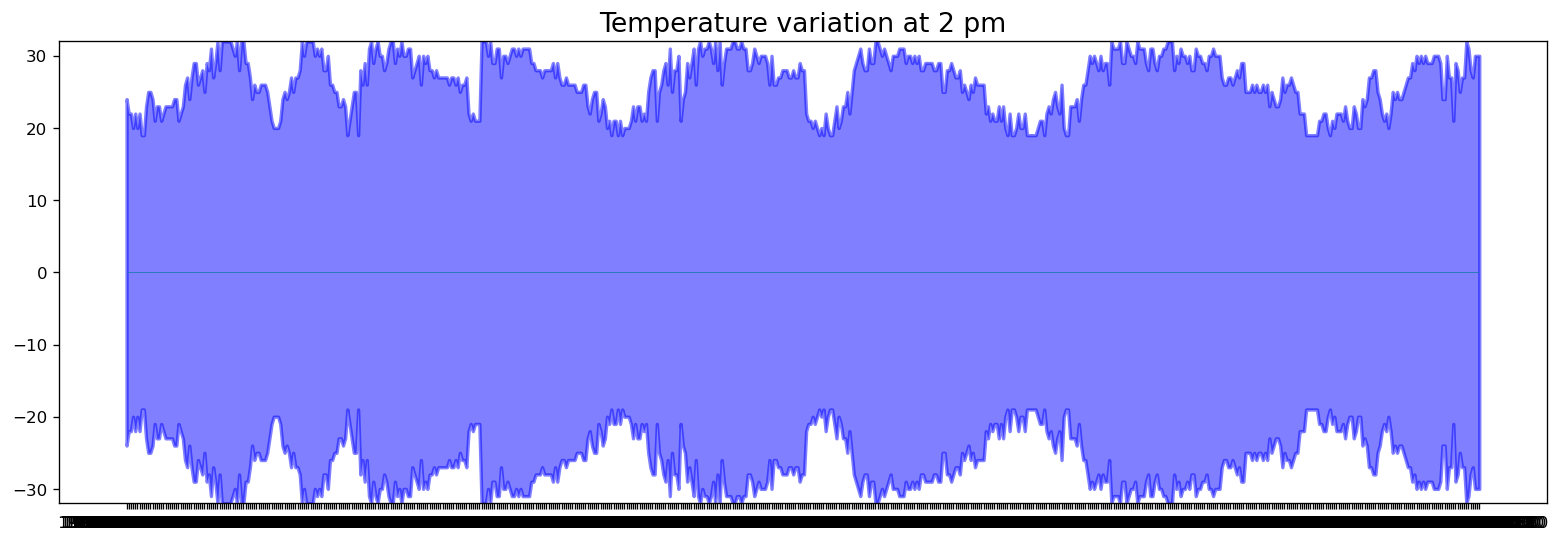

In [121]:
x = temp_df['Date'].values
y1 = temp_df['Temperature'].values

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5), dpi= 120)
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='blue')
plt.ylim(-32, 32)
plt.title('Temperature variation at 2 pm', fontsize=16)
plt.hlines(y=0, xmin=np.min(temp_df.Date), xmax=np.max(temp_df.Date), linewidth=.5)
plt.show()
     


In [122]:
temp_df.tail()

,Date,Temperature,Pressure,Humidity
60182,20040608-14:00,28.0,1002.0,58.0
60183,20040608-14:30,27.0,1002.0,58.0
60226,20040609-14:30,30.0,1003.0,58.0
61463,20040916-14:00,30.0,1007.0,70.0
61464,20040916-14:30,30.0,1008.0,70.0


In [123]:
idx = pd.date_range('1996-11-01 14:00:00', periods=626 , freq='1h')

temp_df = temp_df.set_index(idx)
temp_df.index.name = 'Timestamp' 
temp_df.head()
     

,Date,Temperature,Pressure,Humidity
Timestamp,,,,
1996-11-01 14:00:00,19961101-14:00,24.0,1010.0,41.0
1996-11-01 15:00:00,19961102-14:00,22.0,1010.0,53.0
1996-11-01 16:00:00,19961103-14:00,22.0,1011.0,57.0
1996-11-01 17:00:00,19961106-14:00,20.0,1012.0,52.0
1996-11-01 18:00:00,19961107-14:00,22.0,1014.0,46.0


# Decomposing Time series into its components


In [124]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

result_mul = seasonal_decompose(temp_df['Temperature'], model='multiplicative')

# Additive Decomposition
result_add = seasonal_decompose(temp_df['Temperature'], model='additive')


## Mulplicative Decompose

Text(0.5, 0.98, 'Multiplicative Decompose')

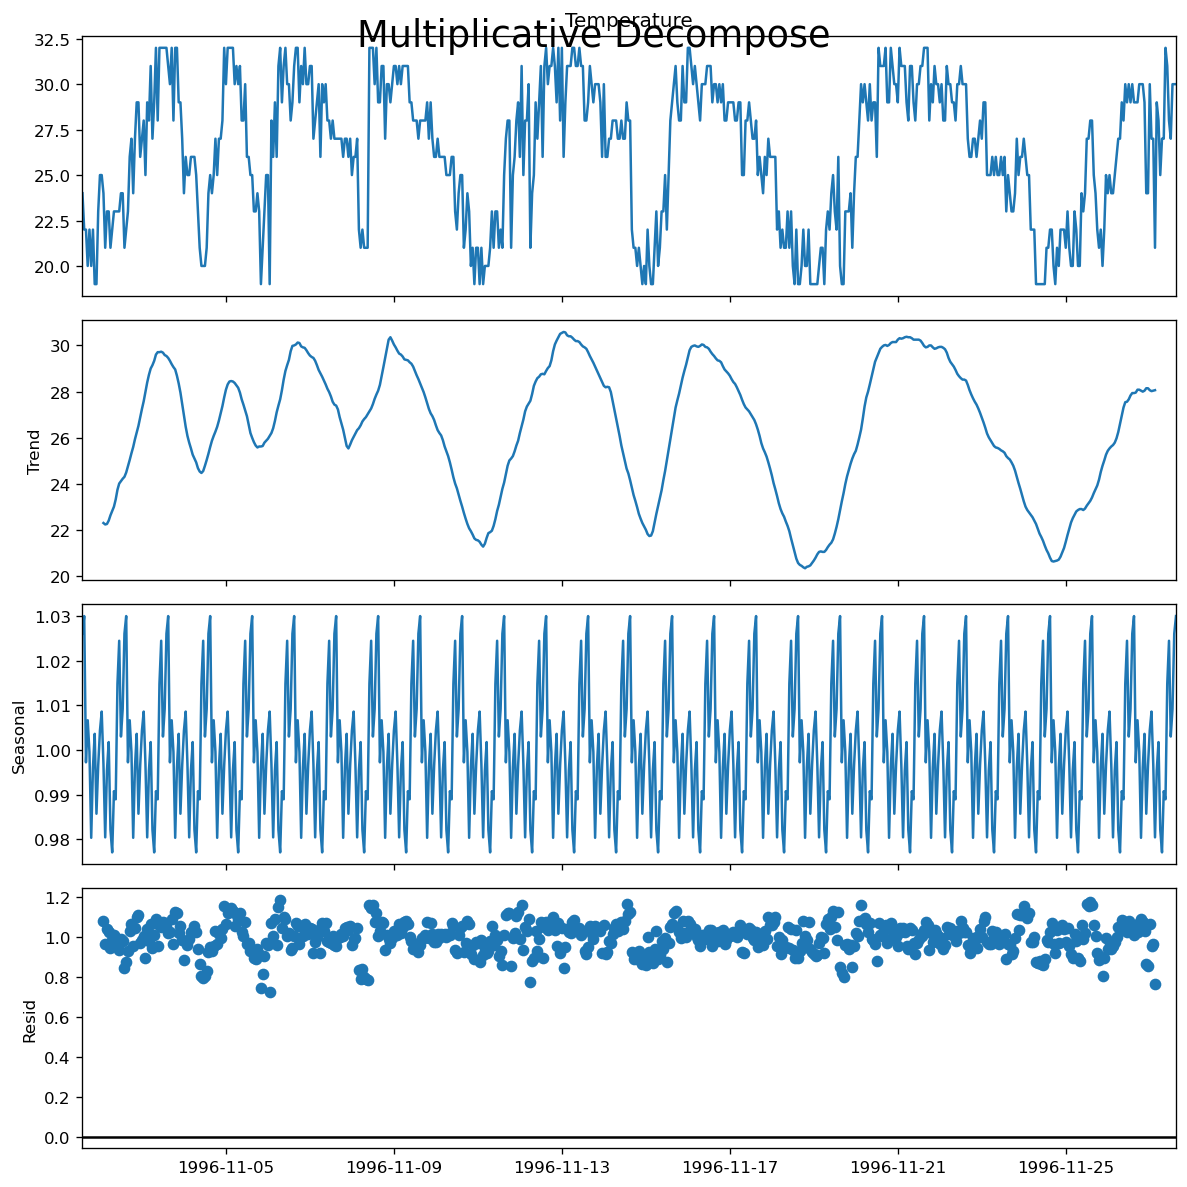

In [125]:
plt.rcParams.update({'figure.figsize': (10,10)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=22)

## Additive Decompose

Text(0.5, 0.98, 'Additive Decompose')

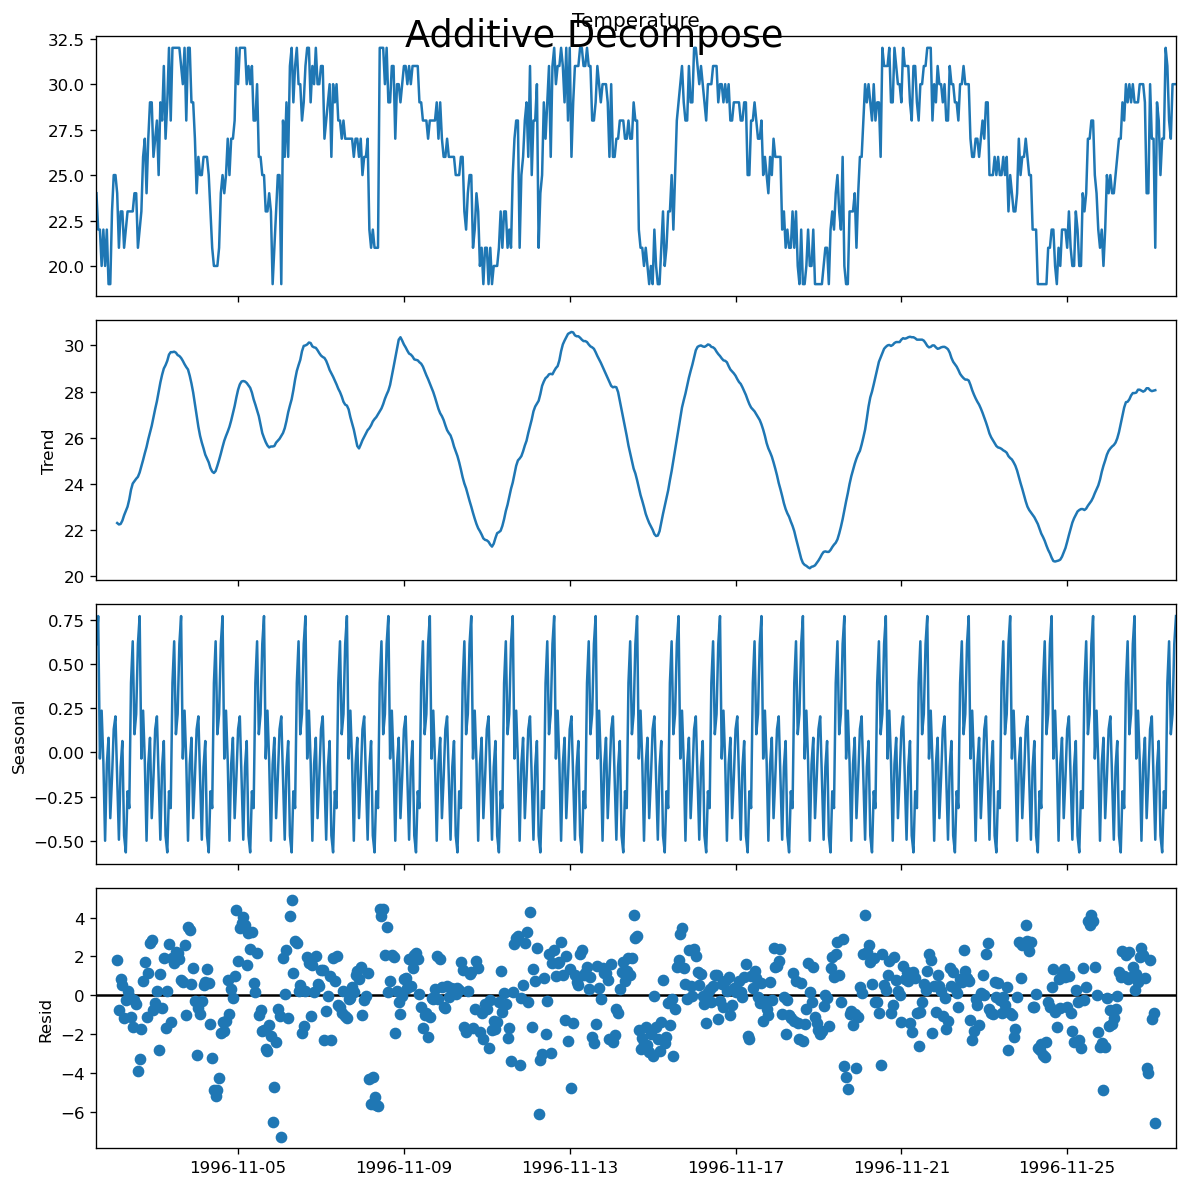

In [126]:
plt.rcParams.update({'figure.figsize': (10,10)})
result_add.plot().suptitle('Additive Decompose', fontsize=22)
     

## Detrend

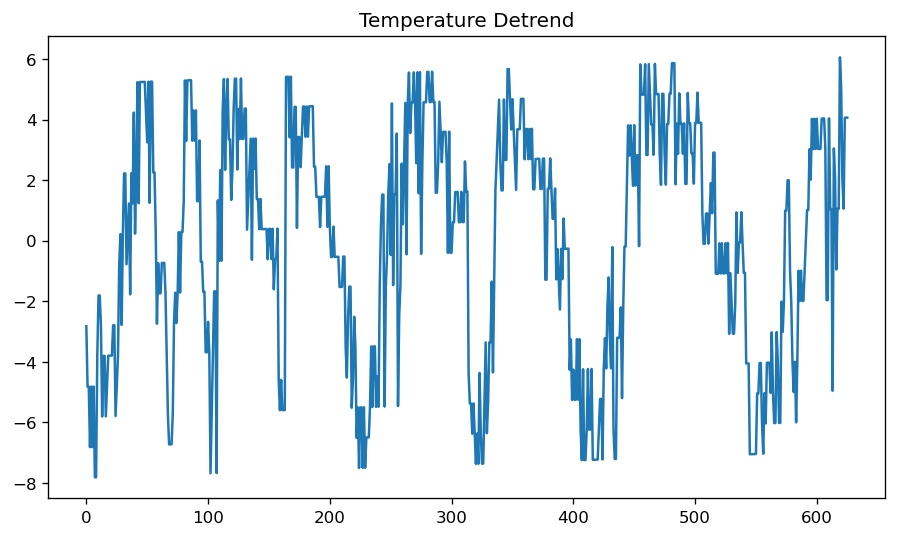

In [127]:
plt.rcParams.update({'figure.figsize': (9,5)})
from scipy import signal
detrended = signal.detrend(temp_df['Temperature'])
plt.title('Temperature Detrend')
plt.plot(detrended)

## Working For ARIMA

### Finding the differencing value

In [128]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(temp_df['Temperature'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
     

ADF Statistic: -4.036295
p-value: 0.001232


## Since the p value is << 0.05 there for series is stationary and we don't actually need to perform differencing

### no differencing (d = 0)

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

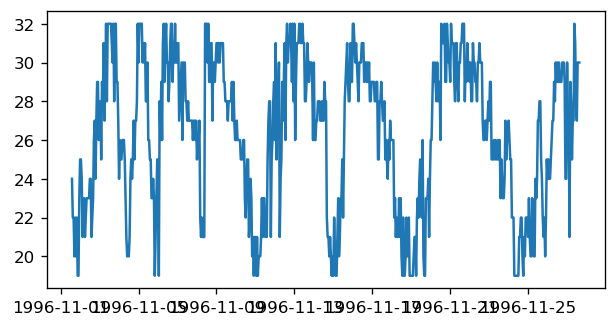

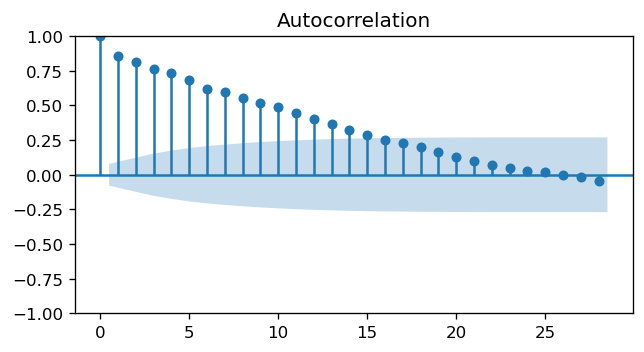

In [129]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})

# Original Series
plt.rcParams.update({'figure.figsize':(6,3), 'figure.dpi':120})
plt.plot(temp_df['Temperature'])
plot_acf(temp_df['Temperature'])
plt.plot

### first order differencing (d = 1)

[]

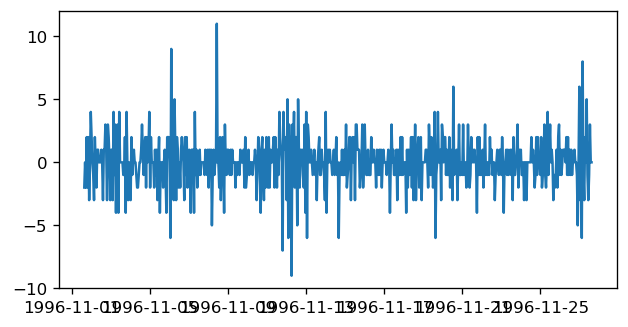

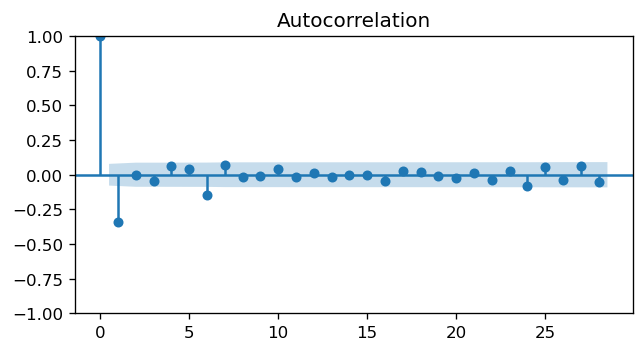

In [130]:
plt.rcParams.update({'figure.figsize':(6,3), 'figure.dpi':120})
plt.plot(temp_df['Temperature'].diff()); 
plot_acf(temp_df['Temperature'].diff().dropna())
plt.plot()
     

## second order differencing (d = 2)

[]

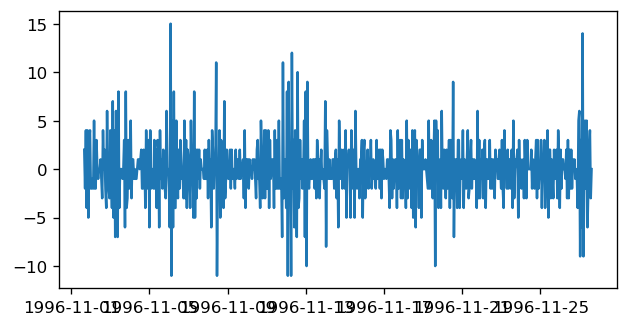

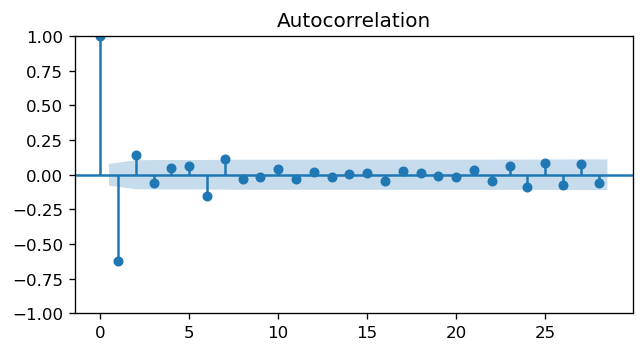

In [131]:

plt.rcParams.update({'figure.figsize':(6,3), 'figure.dpi':120})
plt.plot(temp_df['Temperature'].diff().diff()); 
plot_acf(temp_df['Temperature'].diff().diff().dropna())

plt.plot()

### As we can see, autorelation value quickly becomes negative in the second graph, therefore we fix the value of d as 0

### Finding the order of AR term (p)
### no differencing

[]

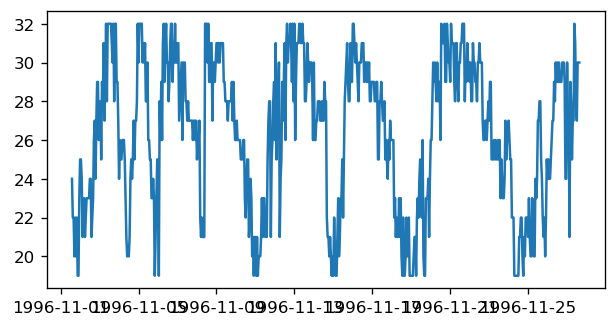

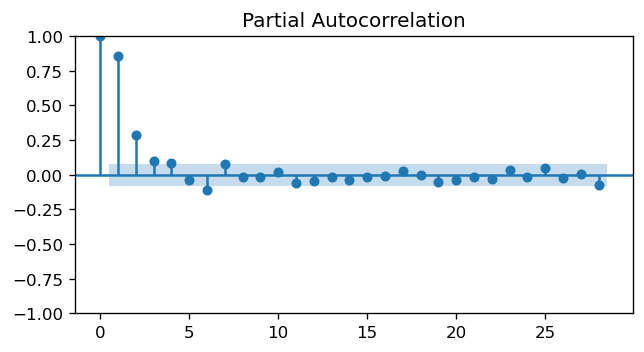

In [132]:
plt.rcParams.update({'figure.figsize':(6,3), 'figure.dpi':120})
plt.plot(temp_df.Temperature)
plot_pacf(temp_df.Temperature.dropna())
plt.plot()


 ### As we can see the first two lines of PACF are significant therefore we keep as 2

#### first order differencing

[]

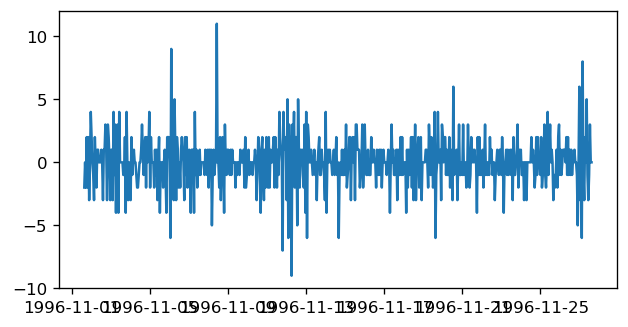

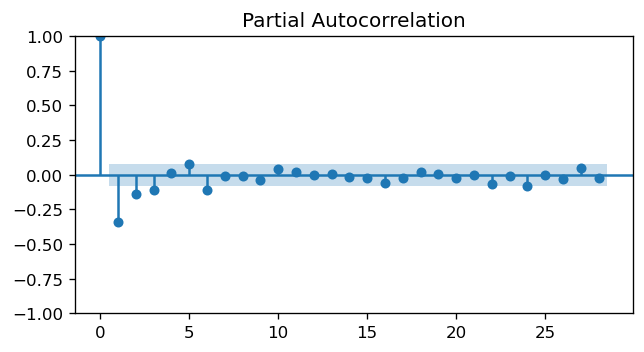

In [133]:

# PACF plot of 1st differenced series
plt.rcParams.update({'figure.figsize':(6,3), 'figure.dpi':120})

plt.plot(temp_df.Temperature.diff())
plot_pacf(temp_df.Temperature.diff().dropna())
plt.plot()
     

#### Finding order of MA term
### no differencing

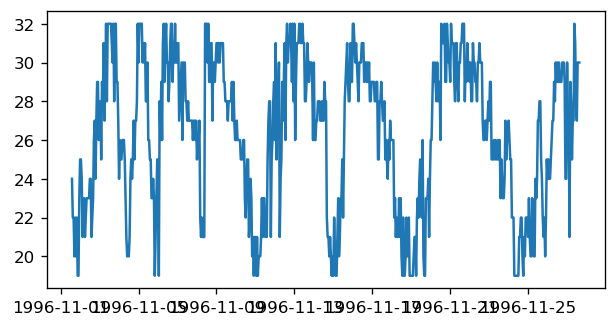

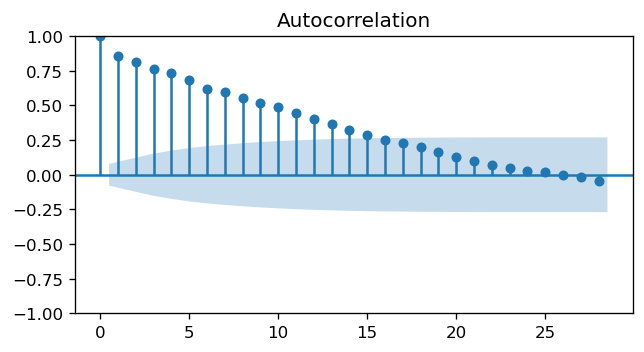

In [134]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams.update({'figure.figsize':(6,3), 'figure.dpi':120})

plt.plot(temp_df.Temperature)
plot_acf(temp_df.Temperature.dropna())

plt.show()

### first order differncing

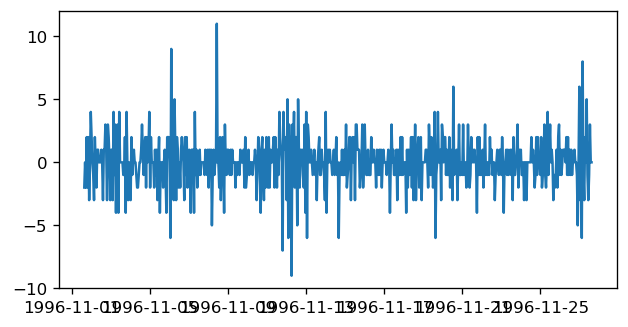

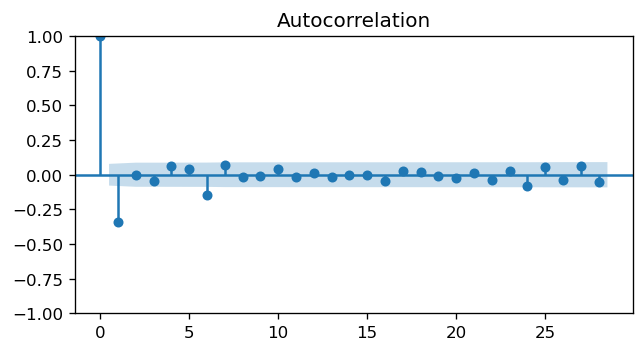

In [135]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams.update({'figure.figsize':(6,3), 'figure.dpi':120})

plt.plot(temp_df.Temperature.diff())
plot_acf(temp_df.Temperature.diff().dropna())

plt.show()
     


### we fix the value of q as 2

In [136]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(temp_df["Temperature"], order=(2,0,2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            Temperature   No. Observations:                  626
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1271.600
Date:                Wed, 04 Mar 2026   AIC                           2555.199
Time:                        20:24:06   BIC                           2581.835
Sample:                    11-01-1996   HQIC                          2565.548
                         - 11-27-1996                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.4973      0.189    139.920      0.000      26.126      26.868
ar.L1          1.9506      0.015    132.886      0.000       1.922       1.979
ar.L2         -0.9529      0.015    -65.622      0.0

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [137]:
train_size = int(len(temp_df) * 0.8)

train = temp_df["Temperature"][:train_size]
test = temp_df["Temperature"][train_size:]

In [138]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            Temperature   No. Observations:                  500
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1018.626
Date:                Wed, 04 Mar 2026   AIC                           2049.253
Time:                        20:24:07   BIC                           2074.540
Sample:                    11-01-1996   HQIC                          2059.175
                         - 11-22-1996                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.6681      0.175    152.100      0.000      26.324      27.012
ar.L1          1.9524      0.015    128.780      0.000       1.923       1.982
ar.L2         -0.9551      0.015    -63.463      0.0

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [139]:
pred_arima = model_fit.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

In [140]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, pred_arima))
mae = mean_absolute_error(test, pred_arima)
mape = np.mean(np.abs((test - pred_arima) / test)) * 100

print("\nARIMA Evaluation Metrics")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


ARIMA Evaluation Metrics
RMSE: 3.3325906516839514
MAE: 2.6781149906635595
MAPE: 11.620998671257196


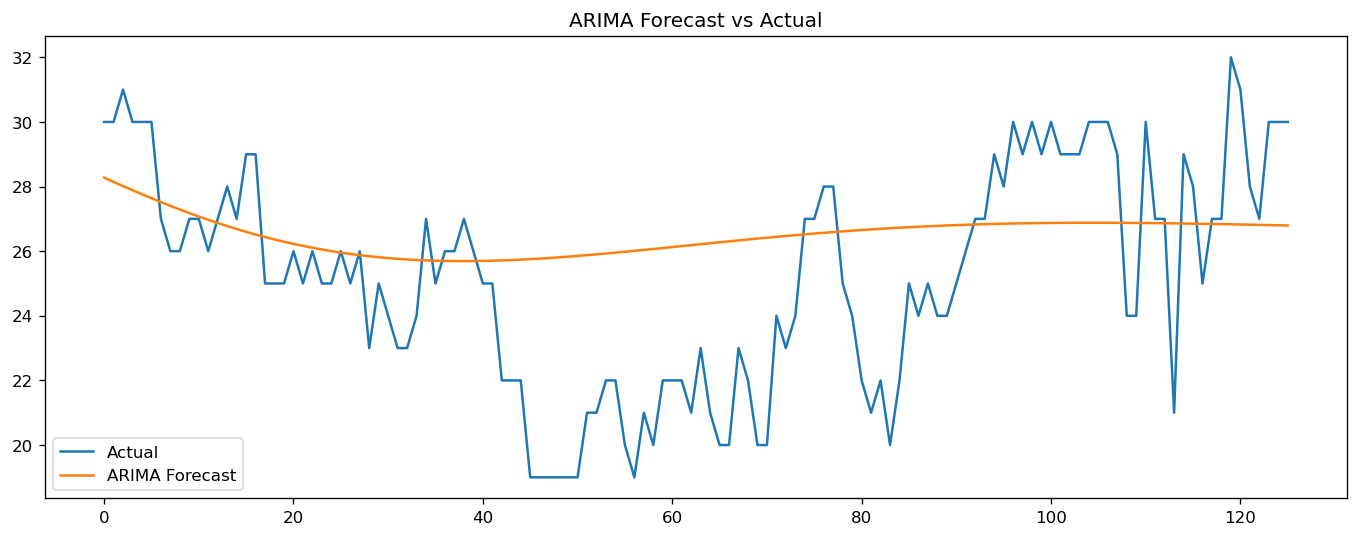

In [141]:
plt.figure(figsize=(14,5))
plt.plot(test.values, label="Actual")
plt.plot(pred_arima.values, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

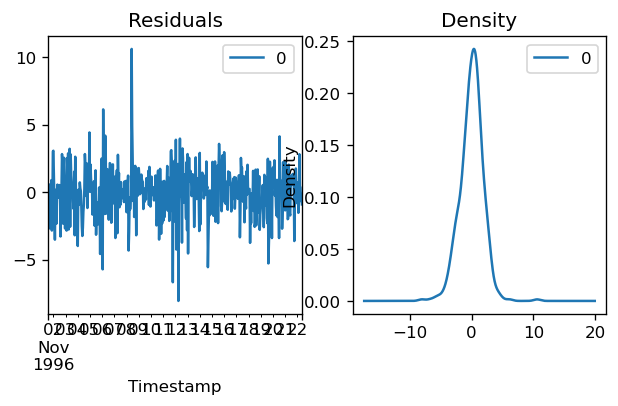

In [142]:
# Plot residual errors
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()
     

In [143]:
pred = model_fit.predict(start=0, end=len(train)-1)

In [144]:
pred = model_fit.get_prediction()
pred_mean = pred.predicted_mean

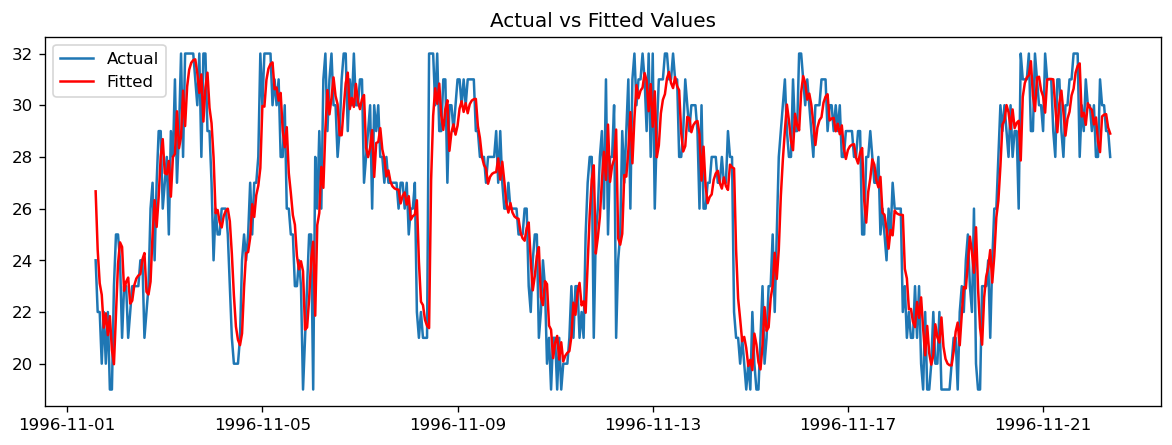

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(train.index, train, label="Actual")
plt.plot(train.index, pred_mean, label="Fitted", color="red")

plt.legend()
plt.title("Actual vs Fitted Values")
plt.show()

# How Do We Predict Future Values?

In [146]:
model_fit = model.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [147]:
future_steps = 24  # predict next 24 hours
forecast = model_fit.forecast(steps=future_steps)

print(forecast)

1996-11-22 10:00:00    28.276319
1996-11-22 11:00:00    28.144485
1996-11-22 12:00:00    28.014591
1996-11-22 13:00:00    27.886901
1996-11-22 14:00:00    27.761659
1996-11-22 15:00:00    27.639094
1996-11-22 16:00:00    27.519415
1996-11-22 17:00:00    27.402816
1996-11-22 18:00:00    27.289473
1996-11-22 19:00:00    27.179545
1996-11-22 20:00:00    27.073175
1996-11-22 21:00:00    26.970490
1996-11-22 22:00:00    26.871601
1996-11-22 23:00:00    26.776605
1996-11-23 00:00:00    26.685584
1996-11-23 01:00:00    26.598602
1996-11-23 02:00:00    26.515715
1996-11-23 03:00:00    26.436962
1996-11-23 04:00:00    26.362368
1996-11-23 05:00:00    26.291949
1996-11-23 06:00:00    26.225707
1996-11-23 07:00:00    26.163633
1996-11-23 08:00:00    26.105707
1996-11-23 09:00:00    26.051898
Freq: H, Name: predicted_mean, dtype: float64
